In [3]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

plt.style.use('ggplot')

In [4]:
# Dataset paths
IMAGE_DIR = "dataset/train/images"
LABEL_DIR = "dataset/train/labels"

# Load file lists
images = sorted(os.listdir(IMAGE_DIR))
labels = sorted(os.listdir(LABEL_DIR))

print(f"Working directory: {os.getcwd()}")

Working directory: /home/payals/snow_pole_project


In [6]:
missing_labels = []

for img in images:
    base_name = os.path.splitext(img)[0]
    label_file = base_name + ".txt"
    
    if label_file not in labels:
        missing_labels.append(img)

print("Total images:", len(images))
print("Total labels:", len(labels))
print("Images without labels:", len(missing_labels))

Total images: 322
Total labels: 322
Images without labels: 0


In [7]:
def show_sample():
    img_name = random.choice(images)
    
    img_path = os.path.join(IMAGE_DIR, img_name)
    label_path = os.path.join(LABEL_DIR, os.path.splitext(img_name)[0] + ".txt")

    img = cv2.imread(img_path)
    h, w, _ = img.shape

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                cls, x, y, bw, bh = map(float, line.split())

                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(img_name)
    plt.show()

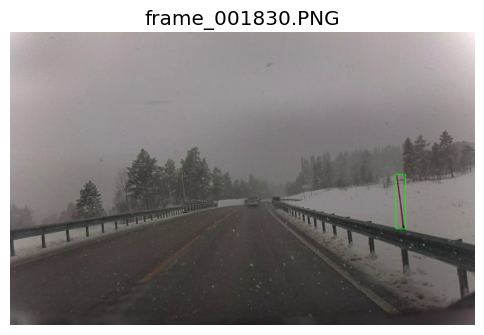

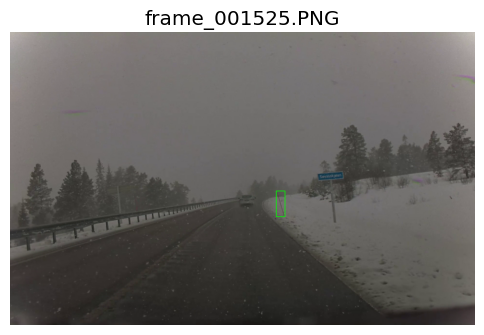

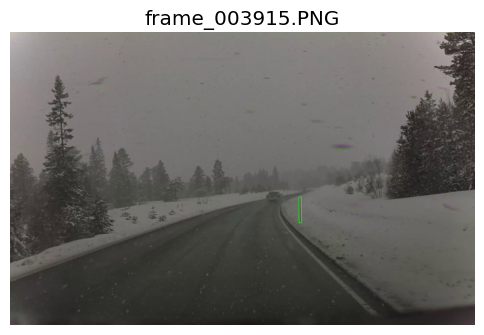

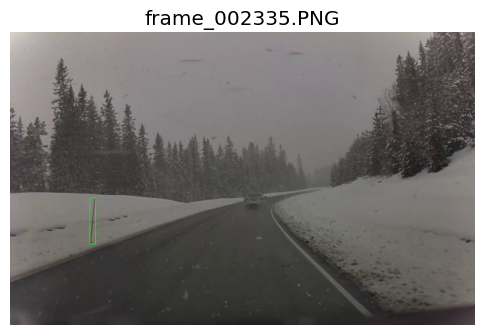

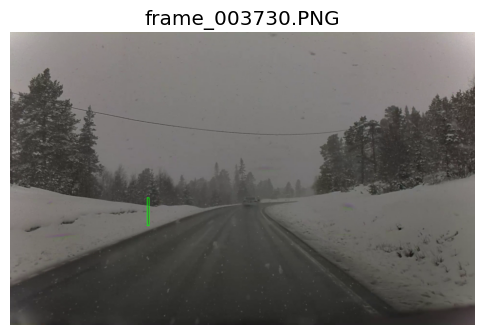

In [8]:
for _ in range(5):
    show_sample()

In [9]:
objects_per_image = []

for file in labels:
    with open(os.path.join(LABEL_DIR, file)) as f:
        count = len(f.readlines())
        objects_per_image.append(count)

# Basic stats
print("Min objects in image:", min(objects_per_image))
print("Max objects in image:", max(objects_per_image))
print("Average objects per image:", np.mean(objects_per_image))

Min objects in image: 1
Max objects in image: 3
Average objects per image: 1.2173913043478262


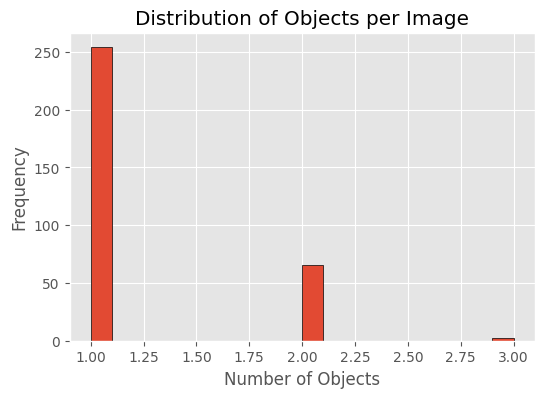

In [10]:
plt.figure(figsize=(6,4))
plt.hist(objects_per_image, bins=20, edgecolor='black')
plt.title("Distribution of Objects per Image")
plt.xlabel("Number of Objects")
plt.ylabel("Frequency")
plt.show()

In [11]:
widths = []
heights = []
areas = []

for file in labels:
    with open(os.path.join(LABEL_DIR, file)) as f:
        for line in f:
            _, _, _, w, h = map(float, line.split())
            widths.append(w)
            heights.append(h)
            areas.append(w * h)

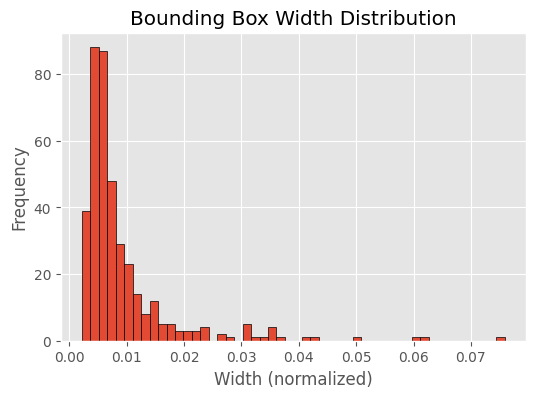

In [12]:
plt.figure(figsize=(6,4))
plt.hist(widths, bins=50, edgecolor='black')
plt.title("Bounding Box Width Distribution")
plt.xlabel("Width (normalized)")
plt.ylabel("Frequency")
plt.show()

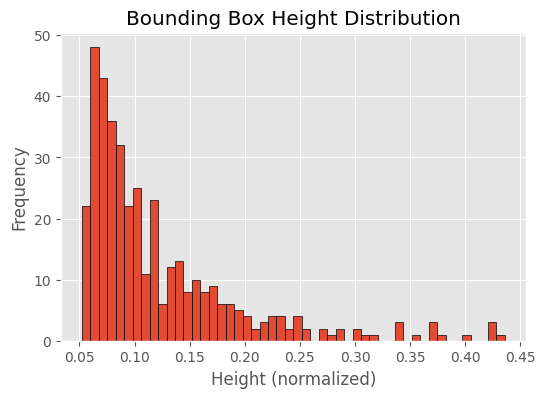

In [13]:
plt.figure(figsize=(6,4))
plt.hist(heights, bins=50, edgecolor='black')
plt.title("Bounding Box Height Distribution")
plt.xlabel("Height (normalized)")
plt.ylabel("Frequency")
plt.show()

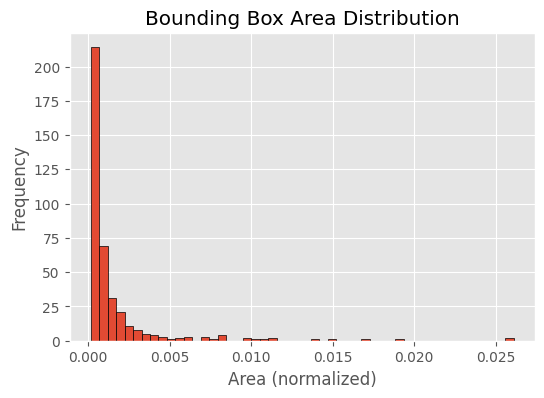

In [14]:
plt.figure(figsize=(6,4))
plt.hist(areas, bins=50, edgecolor='black')
plt.title("Bounding Box Area Distribution")
plt.xlabel("Area (normalized)")
plt.ylabel("Frequency")
plt.show()

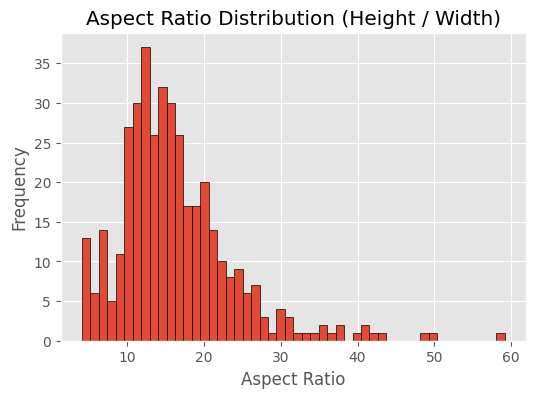

Min aspect ratio: 4.155621623349637
Max aspect ratio: 59.158183480646144
Average aspect ratio: 16.32217172662317


In [15]:
aspect_ratios = [h/w for h, w in zip(heights, widths)]

plt.figure(figsize=(6,4))
plt.hist(aspect_ratios, bins=50, edgecolor='black')
plt.title("Aspect Ratio Distribution (Height / Width)")
plt.xlabel("Aspect Ratio")
plt.ylabel("Frequency")
plt.show()

print("Min aspect ratio:", min(aspect_ratios))
print("Max aspect ratio:", max(aspect_ratios))
print("Average aspect ratio:", np.mean(aspect_ratios))

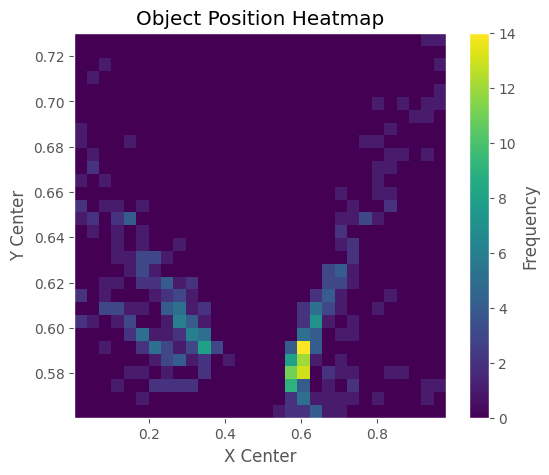

In [16]:
x_centers = []
y_centers = []

for file in labels:
    with open(os.path.join(LABEL_DIR, file)) as f:
        for line in f:
            _, x, y, _, _ = map(float, line.split())
            x_centers.append(x)
            y_centers.append(y)

plt.figure(figsize=(6,5))
plt.hist2d(x_centers, y_centers, bins=30)
plt.colorbar(label="Frequency")
plt.title("Object Position Heatmap")
plt.xlabel("X Center")
plt.ylabel("Y Center")
plt.show()

In [17]:
sizes = []

for img_name in images:
    img = cv2.imread(os.path.join(IMAGE_DIR, img_name))
    sizes.append(img.shape[:2])  # (height, width)

df_sizes = pd.DataFrame(sizes, columns=["height", "width"])

print(df_sizes.describe())

       height   width
count   322.0   322.0
mean   1208.0  1920.0
std       0.0     0.0
min    1208.0  1920.0
25%    1208.0  1920.0
50%    1208.0  1920.0
75%    1208.0  1920.0
max    1208.0  1920.0


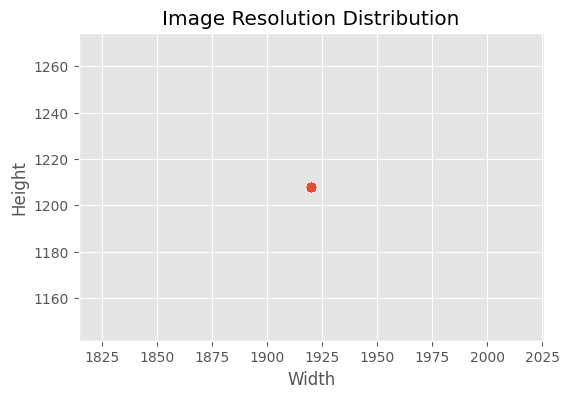

In [18]:
plt.figure(figsize=(6,4))
plt.scatter(df_sizes["width"], df_sizes["height"], alpha=0.5)
plt.title("Image Resolution Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

In [21]:
pixel_widths = []
pixel_heights = []

for img_name in images:
    img = cv2.imread(os.path.join(IMAGE_DIR, img_name))
    h_img, w_img, _ = img.shape
    
    label_file = os.path.splitext(img_name)[0] + ".txt"
    label_path = os.path.join(LABEL_DIR, label_file)
    
    with open(label_path) as f:
        for line in f:
            _, _, _, w, h = map(float, line.split())
            pixel_widths.append(w * w_img)
            pixel_heights.append(h * h_img)

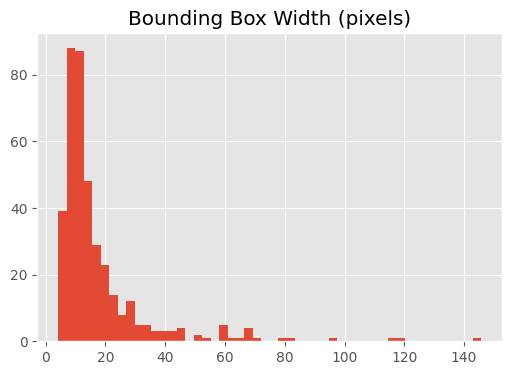

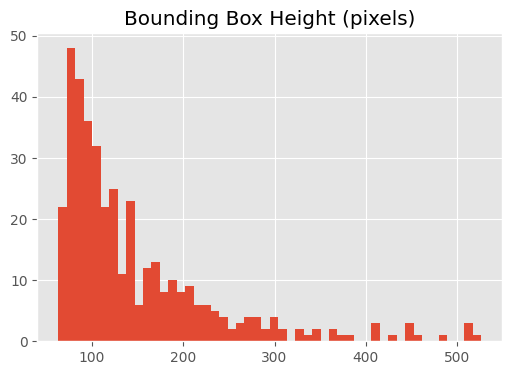

In [22]:
plt.figure(figsize=(6,4))
plt.hist(pixel_widths, bins=50)
plt.title("Bounding Box Width (pixels)")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(pixel_heights, bins=50)
plt.title("Bounding Box Height (pixels)")
plt.show()

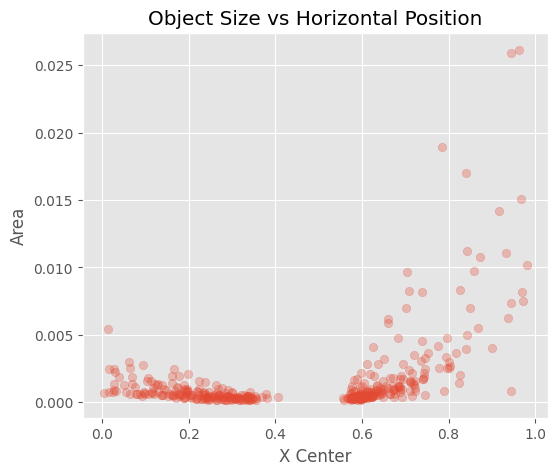

In [23]:
plt.figure(figsize=(6,5))
plt.scatter(x_centers, areas, alpha=0.3)
plt.title("Object Size vs Horizontal Position")
plt.xlabel("X Center")
plt.ylabel("Area")
plt.show()

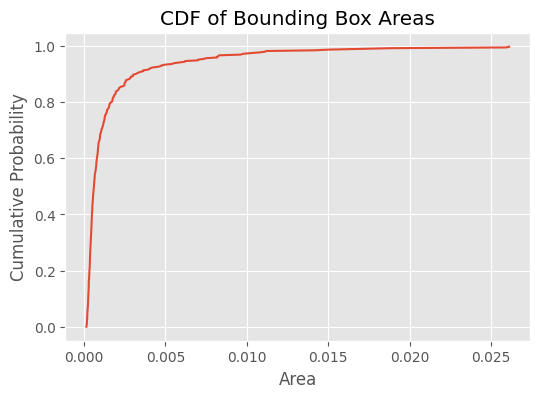

In [24]:
sorted_areas = np.sort(areas)
cdf = np.arange(len(sorted_areas)) / len(sorted_areas)

plt.figure(figsize=(6,4))
plt.plot(sorted_areas, cdf)
plt.title("CDF of Bounding Box Areas")
plt.xlabel("Area")
plt.ylabel("Cumulative Probability")
plt.show()

In [25]:
class_counts = Counter()

for file in labels:
    with open(os.path.join(LABEL_DIR, file)) as f:
        for line in f:
            cls = int(line.split()[0])
            class_counts[cls] += 1

print(class_counts)

Counter({0: 392})


In [26]:
invalid_boxes = []

for file in labels:
    with open(os.path.join(LABEL_DIR, file)) as f:
        for line in f:
            _, x, y, w, h = map(float, line.split())
            
            if w <= 0 or h <= 0 or w > 1 or h > 1:
                invalid_boxes.append((file, w, h))

print("Invalid boxes:", len(invalid_boxes))

Invalid boxes: 0


In [27]:
edge_objects = 0
total_objects = 0

for file in labels:
    with open(os.path.join(LABEL_DIR, file)) as f:
        for line in f:
            _, x, y, w, h = map(float, line.split())
            total_objects += 1
            
            if x < 0.1 or x > 0.9:
                edge_objects += 1

print("Edge objects (%):", edge_objects / total_objects * 100)

Edge objects (%): 9.948979591836734


In [28]:
def iou(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    
    # convert to corners
    x1_min, x1_max = x1 - w1/2, x1 + w1/2
    y1_min, y1_max = y1 - h1/2, y1 + h1/2
    
    x2_min, x2_max = x2 - w2/2, x2 + w2/2
    y2_min, y2_max = y2 - h2/2, y2 + h2/2
    
    inter_x1 = max(x1_min, x2_min)
    inter_y1 = max(y1_min, y2_min)
    inter_x2 = min(x1_max, x2_max)
    inter_y2 = min(y1_max, y2_max)
    
    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    area1 = w1 * h1
    area2 = w2 * h2
    
    return inter_area / (area1 + area2 - inter_area + 1e-6)

In [30]:
ious = []

for file in labels:
    boxes = []
    
    with open(os.path.join(LABEL_DIR, file)) as f:
        for line in f:
            _, x, y, w, h = map(float, line.split())
            boxes.append((x, y, w, h))
    
    # compare all pairs in same image
    for i in range(len(boxes)):
        for j in range(i+1, len(boxes)):
            ious.append(iou(boxes[i], boxes[j]))

print("Total overlapping pairs checked:", len(ious))

Total overlapping pairs checked: 72


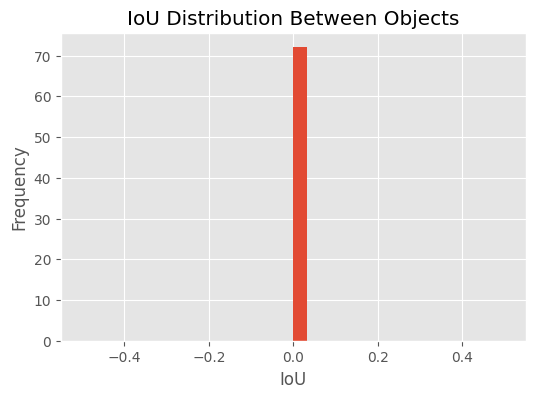

Average IoU: 0.0
Max IoU: 0.0


In [31]:
plt.figure(figsize=(6,4))
plt.hist(ious, bins=30)
plt.title("IoU Distribution Between Objects")
plt.xlabel("IoU")
plt.ylabel("Frequency")
plt.show()

if len(ious) > 0:
    print("Average IoU:", np.mean(ious))
    print("Max IoU:", max(ious))

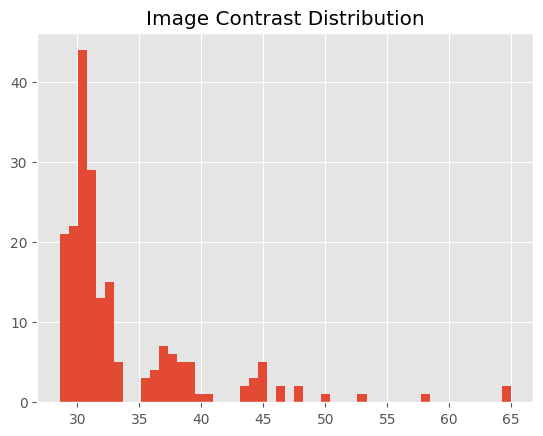

In [29]:
contrast = []

for img_name in images[:200]:
    img = cv2.imread(os.path.join(IMAGE_DIR, img_name))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    contrast.append(gray.std())

plt.hist(contrast, bins=50)
plt.title("Image Contrast Distribution")
plt.show()

In [32]:
orientation = []

for w, h in zip(widths, heights):
    orientation.append(h / (w + 1e-6))

print("Mean orientation:", np.mean(orientation))

Mean orientation: 16.319197416037593


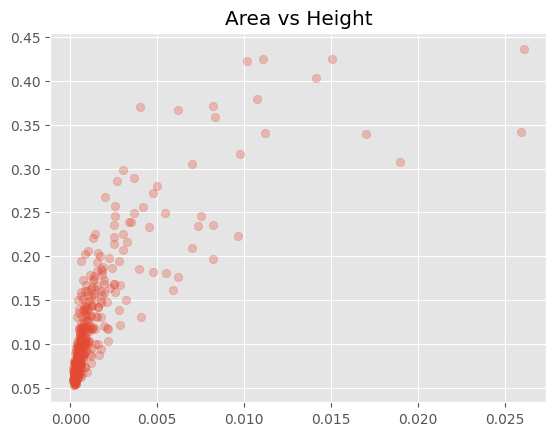

In [33]:
plt.scatter(areas, heights, alpha=0.3)
plt.title("Area vs Height")
plt.show()

In [34]:
TRAIN_IMAGE_DIR = "dataset/train/images"
TRAIN_LABEL_DIR = "dataset/train/labels"

VAL_IMAGE_DIR = "dataset/valid/images"
VAL_LABEL_DIR = "dataset/valid/labels"

In [35]:
def extract_stats(label_dir):
    objects_per_image = []
    widths = []
    heights = []
    aspect_ratios = []

    label_files = os.listdir(label_dir)

    for file in label_files:
        with open(os.path.join(label_dir, file)) as f:
            lines = f.readlines()
            objects_per_image.append(len(lines))

            for line in lines:
                _, _, _, w, h = map(float, line.split())
                widths.append(w)
                heights.append(h)
                aspect_ratios.append(h / (w + 1e-6))

    return {
        "objects_per_image": objects_per_image,
        "widths": widths,
        "heights": heights,
        "aspect_ratios": aspect_ratios
    }

In [36]:
train_stats = extract_stats(TRAIN_LABEL_DIR)
val_stats = extract_stats(VAL_LABEL_DIR)

In [37]:
print("TRAIN avg objects:", np.mean(train_stats["objects_per_image"]))
print("VAL avg objects:", np.mean(val_stats["objects_per_image"]))

TRAIN avg objects: 1.2173913043478262
VAL avg objects: 1.2282608695652173


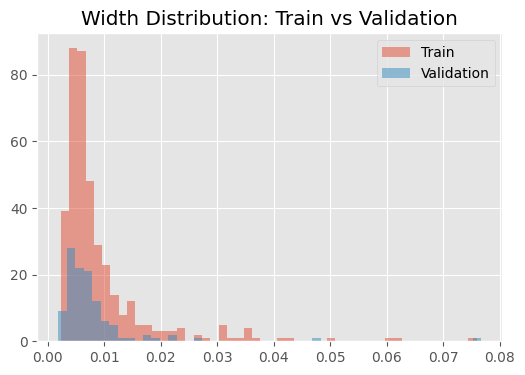

In [39]:
plt.figure(figsize=(6,4))
plt.hist(train_stats["widths"], bins=50, alpha=0.5, label="Train")
plt.hist(val_stats["widths"], bins=50, alpha=0.5, label="Validation")
plt.title("Width Distribution: Train vs Validation")
plt.legend()
plt.show()

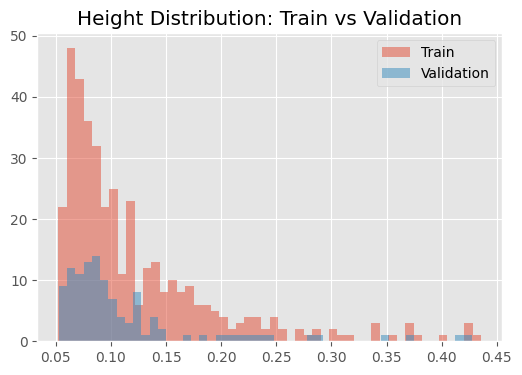

In [40]:
plt.figure(figsize=(6,4))
plt.hist(train_stats["heights"], bins=50, alpha=0.5, label="Train")
plt.hist(val_stats["heights"], bins=50, alpha=0.5, label="Validation")
plt.title("Height Distribution: Train vs Validation")
plt.legend()
plt.show()

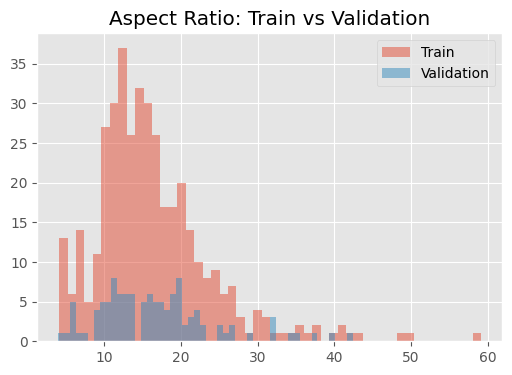

In [41]:
plt.figure(figsize=(6,4))
plt.hist(train_stats["aspect_ratios"], bins=50, alpha=0.5, label="Train")
plt.hist(val_stats["aspect_ratios"], bins=50, alpha=0.5, label="Validation")
plt.title("Aspect Ratio: Train vs Validation")
plt.legend()
plt.show()